# Scope of the American Parliamentary Debate Association (APDA)

This section will analzye the scope and patterns seen within the APDA circuit from Fall 2019 to Spring 2026 using the following metrics: tournaments, rounds, and number of debaters. The goal of this section is to understand the scope of APDA and its expected impact in coming years.

## Tournaments

The first metric to understand is the number of tournaments in APDA between Fall 2019 and Spring 2026 as well as the number of tournaments per semester. In order to begin understanding this, I will import the rounds from Fall 2019 to Spring 2026. This data includes information on all the rounds conducted at tournaments with accessible tab cards between Fall 2019 and Spring 2026, this also includes information on the speakers, judges, and decisions. These are not relevant for this analysis so we will drop this extra information and begin by tallying the number of rounds per tournament to utilize in the Rounds section. I will do this with a SQL query.

In [6]:
import duckdb
import pandas as pd

df_rounds = pd.read_csv("Data_Curation_Data/Rounds_Final_Debater_Restoration.csv")
con = duckdb.connect()
con.register('rounds', df_rounds)

query = """
SELECT tournament, season, year, COUNT(*) AS 'total_rounds' 
FROM rounds
WHERE round != 6
GROUP BY tournament, season, year
"""

df_rounds_collapsed = con.execute(query).df()

In addition to the tournaments seen in the "Rounds_After_Debater_Restoration.csv", there were also tournaments that could not be processed due to bad format, lack of permission, or because they simply had never been uploaded. The code below will append these lost tournaments to our df_rounds_collapsed dataset which contains information about tournament, season, year, and number of rounds from that tournament. I will append these tournaments to our dataframe so they will be included in our analysis. Further, for some tournaments, even though the tab cards are unavaliable, the schools provided a blurb about the number of teams that attended at least three rounds. I used this information to make an educated guess about the number of rounds recorded at that tournament, though these numbers may be slightly off from the true rounds due to missed rounds or dropped rounds.

In [7]:
data = [
    {'tournament': 'Fordham', 'season': 'Fall', 'year': 2019},
    {'tournament': 'University of Virginia', 'season': 'Fall', 'year': 2019, 'total_rounds': 55}, # 22 teams, 11 rounds * 5 = 55
    {'tournament': 'Columbia', 'season': 'Fall', 'year': 2019, 'total_rounds': 245}, # 98 teams, 49 rounds * 5 = 245
    {'tournament': 'Georgetown', 'season': 'Spring', 'year': 2020, 'total_rounds': 165}, # 66 teams, 33 rounds * 5 = 165
    {'tournament': 'Williams', 'season': 'Spring', 'year': 2020, 'total_rounds': 55}, # 23 teams, 11 rounds * 5 = 55
    {'tournament': 'Harvard/Pitt', 'season': 'Fall', 'year': 2020},
    {'tournament': 'Swarthmore', 'season': 'Spring', 'year': 2021, 'total_rounds': 105}, # 43 teams, 21 rounds * 5 = 105 
    {'tournament': 'Brandeis', 'season': 'Spring', 'year': 2021, 'total_rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'tournament': 'William and Mary/CUNY/Stanford', 'season': 'Spring', 'year': 2021},
    {'tournament': 'Georgetown/Williams', 'season': 'Spring', 'year': 2021, 'total_rounds': 75}, # 31 teams, 15 rounds * 5 = 75
    {'tournament': 'Yale', 'season': 'Spring', 'year': 2021, 'total_rounds': 120}, # 49 teams, 24 rounds * 5 = 120
    {'tournament': 'Brown', 'season': 'Fall', 'year': 2021, 'total_rounds': 55}, # 35 teams, 11 rounds * 5 = 55
    {'tournament': 'Brown', 'season': 'Spring', 'year': 2022, 'total_rounds': 65}, # 26 teams, 13 rounds * 5 = 65
    {'tournament': 'Princeton', 'season': 'Spring', 'year': 2022, 'total_rounds': 105}, # 43 teams, 21 rounds * 5 = 105 
    {'tournament': 'Yale', 'season': 'Spring', 'year': 2022, 'total_rounds': 90}, # 36 teams, 18 rounds * 5 = 90
    {'tournament': 'Rutgers', 'season': 'Spring', 'year': 2022, 'total_rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'tournament': 'Williams', 'season': 'Spring', 'year': 2022, 'total_rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'tournament': 'Brown', 'season': 'Fall', 'year': 2022, 'total_rounds': 140},  # 56 teams, 28 rounds * 5 = 140
    {'tournament': 'Tufts', 'season': 'Fall', 'year': 2022, 'total_rounds': 115}, # 46 teams, 23 rounds * 5 = 115
    {'tournament': 'Harvard', 'season': 'Fall', 'year': 2022, 'total_rounds': 210}, # 85 teams, 42 rounds * 5 = 210
    {'tournament': 'Hopkins', 'season': 'Spring', 'year': 2023, 'total_rounds': 30}, # 30 teams, 15 rounds * 5 = 75
    {'tournament': 'Brandeis', 'season': 'Spring', 'year': 2023, 'total_rounds': 40}, # 17 teams, 8 rounds * 5 = 40
    {'tournament': 'Rutgers', 'season': 'Spring', 'year': 2023, 'total_rounds': 170}, # 68 teams, 34 rounds * 5 = 170
    {'tournament': 'Penn', 'season': 'Spring', 'year': 2023, 'total_rounds': 80}, # 33 teams, 16 rounds * 5 = 80 
    {'tournament': 'Williams', 'season': 'Spring', 'year': 2023, 'total_rounds': 45}, # 18 teams, 9 rounds * 5 = 45 
    {'tournament': 'University of Chicago', 'season': 'Spring', 'year': 2023, 'total_rounds': 45}, # 19 teams, 9 rounds * 5 = 45 
    {'tournament': 'Brandeis', 'season': 'Fall', 'year': 2023, 'total_rounds': 45}, # 18 teams, 9 rounds * 5 = 45 
    {'tournament': 'Harvard', 'season': 'Fall', 'year': 2023, 'total_rounds': 280}, # 112 teams, 56 rounds * 5 = 280
    {'tournament': 'Brandeis', 'season': 'Spring', 'year': 2024, 'total_rounds': 60}, # 24 teams, 12 rounds * 5 = 60 
    {'tournament': 'Tufts', 'season': 'Spring', 'year': 2024, 'total_rounds': 115}, # 46 teams, 23 rounds * 5 = 115 
    {'tournament': 'Harvard', 'season': 'Fall', 'year': 2024, 'total_rounds': 305}, # 123 teams, 61 rounds * 5 = 305
    {'tournament': 'Tufts', 'season': 'Fall', 'year': 2024, 'total_rounds': 125}, # 50 teams, 25 rounds * 5 = 125
    {'tournament': 'Rutgers', 'season': 'Spring', 'year': 2025, 'total_rounds': 110}, # 45 teams, 22 rounds * 5 = 110
    {'tournament': 'Brandeis', 'season': 'Fall', 'year': 2025, 'total_rounds': 40}, # 17 teams, 8 rounds * 5 = 40
    {'tournament': 'Penn', 'season': 'Spring', 'year': 2025, 'total_rounds': 160}, # 64 teams, 32 rounds * 5 = 160
    {'tournament': 'Drexel', 'season': 'Fall', 'year': 2025, 'total_rounds': 55}, # 22 teams, 11 rounds * 5 = 55 
    {'tournament': 'Bates', 'season': 'Fall', 'year': 2025, 'total_rounds': 60}, # 25 teams, 12 rounds * 5 = 60 
    {'tournament': 'Binghamton', 'season': 'Fall', 'year': 2024, 'total_rounds': 30}, # 13 teams, 6 rounds * 5 = 30 
    {'tournament': 'Amherst', 'season': 'Spring', 'year': 2024, 'total_rounds': 65}, # 26 teams, 13 rounds * 5 = 65 
    {'tournament': 'Amherst', 'season': 'Spring', 'year': 2025, 'total_rounds': 100}, # 40 teams, 20 rounds * 5 = 100
    {'tournament': 'American', 'season': 'Fall', 'year': 2025},
    {'tournament': 'Temple', 'season': 'Spring', 'year': 2026, 'total_rounds': 130}, # 52 teams, 26 rounds * 5 = 130
    {'tournament': 'UT Austin', 'season': 'Spring', 'year': 2025},
    {'tournament': 'Swarthmore', 'season': 'Fall', 'year': 2023, 'total_rounds': 60}, # 25 teams, 12 rounds * 5 = 60 rounds
    {'tournament': 'University of Virginia', 'season': 'Spring', 'year': 2025, 'total_rounds':90}, # 36 teams, 18 rounds * 5 = 90
    {'tournament': 'Dartmouth', 'season': 'Spring', 'year': 2025},
    {'tournament': 'Brown', 'season': 'Fall', 'year': 2024, 'total_rounds': 255}, # 102 teams, 51 rounds * 5 = 255
    {'tournament': 'University of Massachusetts', 'season': 'Spring', 'year': 2024, 'total_rounds': 40}, # 17 teams, 8 rounds * 5 = 40 
    {'tournament': 'NYU', 'season': 'Spring', 'year': 2024, 'total_rounds': 75}, # 31 teams, 15 rounds * 5 = 75
    {'tournament': 'Windsor', 'season': 'Spring', 'year': 2024, 'total_rounds': 65}, # 27 teams, 13 rounds * 5 = 65
    {'tournament': 'University of Massachusetts', 'season': 'Spring', 'year': 2023, 'total_rounds': 60}, # 25 teams, 12 rounds * 5 = 60
    {'tournament': 'Rutgers', 'season': 'Fall', 'year': 2022}, 
    {'tournament': 'Dartmouth', 'season': 'Spring', 'year': 2022, 'total_rounds': 60}, # 25 teams, 12 rounds * 5 = 60
    {'tournament': 'Yale', 'season': 'Fall', 'year': 2022},
    {'tournament': 'Williams', 'season': 'Fall', 'year': 2022}, 
]
missing_df = pd.DataFrame(data)

In order to make these numbers more like the true rounds, I want to calculate the number of "dropped rounds" or rounds where there were teams registered but that were rounds that never actually occurred. Reasons for such rounds could include the following: a team was late, a team did not show up for day two, a team skipped a round for personal reasons. If we can find the average percentage of dropped rounds, we can emulate natural drop off in the tournaments where we only have team information, not round information. The code below selects and displays the total number of individual rounds recorded in each of the five rounds.

In [8]:
query = """
SELECT COUNT(*) AS 'total_rounds' 
FROM rounds
WHERE round != 6
GROUP BY round 
ORDER BY round ASC
"""

attended = con.execute(query).df()
attended.index = attended.index + 1
print(attended.head())

   total_rounds
1          3243
2          3282
3          3247
4          3183
5          3091


The above shows the total number of rounds that occurred in rounds one through five at tournaments from Fall 2019 to Spring 2026. I will assume all debaters who will turn up for a tournament do so by round two. If this is true we can calculate a percentage of how many rounds are missed in rounds one, three, four, and five.

In [9]:
max_rounds = float(attended.iat[1,0])
total_rounds = attended.loc[1:5].astype(float).sum()
total_normalized_rounds = total_rounds / 5
percentage = 1 - (total_normalized_rounds/max_rounds)
print(f"Percentage of Rounds Dropped: ", percentage.iat[0])

Percentage of Rounds Dropped:  0.022181596587446784


Under these assumptions, the above shows us that in total only 2.22% of all rounds are dropped. Due to this, we can take the estimated values from the number of teams and use a multiplier to mimic the dropped rounds seen across other tournaments. I will also add a new column "semester" which combines the Season and Year columns as a string in order to act as a label for graphs in the future.

In [10]:
import numpy as np

missing_df['total_rounds'] = np.ceil(missing_df['total_rounds'] * .978) # Mimic normal dropping patterns
tournament_rounds_df = pd.concat([df_rounds_collapsed, missing_df], ignore_index=True)
tournament_rounds_df["semester"] = tournament_rounds_df["season"] + " " + tournament_rounds_df["year"].astype(str)

print(tournament_rounds_df.tail())
tournament_rounds_df.to_csv("APDA_Scope_Data/Tournament_Rounds.csv", index=False)

                      tournament  season  year  total_rounds     semester
236  University of Massachusetts  Spring  2023          59.0  Spring 2023
237                      Rutgers    Fall  2022           NaN    Fall 2022
238                    Dartmouth  Spring  2022          59.0  Spring 2022
239                         Yale    Fall  2022           NaN    Fall 2022
240                     Williams    Fall  2022           NaN    Fall 2022


We can now see our tournaments with missing detailed round data have been appened onto the end of our dataframe, so we now have a record of all of our tournaments that took place.

In [11]:
print("Total Tournaments from Fall 2019 to Spring 2026: ", tournament_rounds_df["tournament"].count())

Total Tournaments from Fall 2019 to Spring 2026:  241


There were a total of 241 tournaments between Fall 2019 and Spring 2026.

Now we can begin to analyze the number of tournaments over time in APDA. To do this, we will group out tournament_rounds_df by Semester leaving a count of the number of tournaments that occurred in each semester. I will also adjust the order of the semesters to be chronological.

In [12]:
con.register('tournament_rounds', tournament_rounds_df)

query = """
SELECT semester, COUNT(*) as tournament_count
FROM tournament_rounds
GROUP BY Semester
ORDER BY (
     case semester 
     when 'Fall 2019' then 0 
     when 'Spring 2020' then 1
     when 'Fall 2020' then 2
     when 'Spring 2021' then 3
     when 'Fall 2021' then 4
     when 'Spring 2022' then 5
     when 'Fall 2022' then 6
     when 'Spring 2023' then 7
     when 'Fall 2023' then 8
     when 'Spring 2024' then 9
     when 'Fall 2024' then 10
     when 'Spring 2025' then 11
     when 'Fall 2025' then 12
     when 'Spring 2026' then 13
     end     
)
"""
tournaments_df = con.execute(query).df()

We will also drop the seasons that occurred during the COVID-19 in-person restriction era, so that we can see our data with and without this outlier data.

In [13]:
con.register('tournament_rounds', tournaments_df)

query = """
SELECT semester, tournament_count
FROM tournament_rounds
WHERE (
    (semester != 'Spring 2020') AND
    (semester != 'Fall 2020') AND
    (semester != 'Spring 2021') AND
    (semester != 'Fall 2021')
)
"""
tournaments_df_exclude_covid = con.execute(query).df()

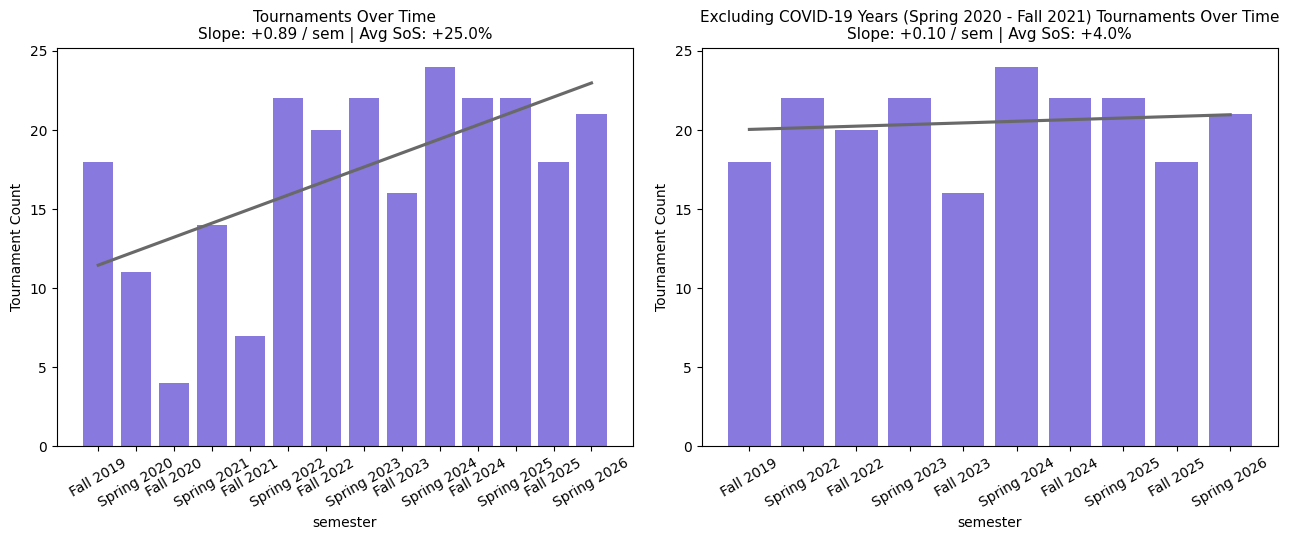

In [14]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import seaborn as sns

x_positions_t = np.arange(len(tournaments_df))
slope_t, _ = np.polyfit(x_positions_t, tournaments_df["tournament_count"], 1)
avg_pct_t = tournaments_df["tournament_count"].pct_change().mean() * 100

x_positions_r = np.arange(len(tournaments_df_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, tournaments_df_exclude_covid["tournament_count"], 1)
avg_pct_r = tournaments_df_exclude_covid["tournament_count"].pct_change().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(tournaments_df, x="semester", y="tournament_count", color="mediumslateblue", ax=axes[0],)
sns.regplot(x=x_positions_t, y=tournaments_df["tournament_count"], ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None)

axes[0].set_title(f"Tournaments Over Time\nSlope: {slope_t:+.2f} / sem | Avg SoS: {avg_pct_t:+.1f}%", fontsize=11)
axes[0].set_ylabel("Tournament Count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot( tournaments_df_exclude_covid, x="semester", y="tournament_count", color="mediumslateblue", ax=axes[1])
sns.regplot(x=x_positions_r, y=tournaments_df_exclude_covid["tournament_count"], ax=axes[1], scatter=False, color="dimgray",
    label="Trend", ci=None)

axes[1].set_title(
    f"Excluding COVID-19 Years (Spring 2020 - Fall 2021) Tournaments Over Time\nSlope: {slope_r:+.2f} / sem | Avg SoS: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Tournament Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In the excluding COVID-19 years graph (right), there is a slope of +0.10 a semester and has an average semester-over-semester increase of +4.0%. This may indicate that the number of tournaments continue to grow in ADPA. However, it seems that there might be a difference between the number of tournaments hosted in Spring semesters and the number in Fall semesters. This pattern seems like it could even be cyclic in nature. This could affect how we interpret growth in this graph. I will investigate this using a Mann U Whitney test since the sample size is so small (n=5) that we cannot safely test for normal distribution that would be required for a Two Sample T-Test. My hypothesis is that there is a difference between the Spring and Fall semesters.

In [15]:
from scipy.stats import mannwhitneyu
valid_fall = ["Fall 2019", "Fall 2022", "Fall 2023", "Fall 2024", "Fall 2025"]
valid_spring = ["Spring 2022", "Spring 2023", "Spring 2024", "Spring 2025", "Spring 2026"]

fall = pd.Series()
spring = pd.Series()

fall["tournament_count"] = tournaments_df[tournaments_df["semester"].isin(valid_fall)]["tournament_count"].copy()
spring["tournament_count"] = tournaments_df[tournaments_df["semester"].isin(valid_spring)]["tournament_count"].copy()

fall_array = fall['tournament_count'].to_numpy()
spring_array = spring['tournament_count'].to_numpy()

U1, p = mannwhitneyu(fall_array, spring_array, alternative='two-sided', method="exact")
print("U: ", U1)
print("p-value: ", p)

U:  2.5
p-value:  0.05555555555555555


From the Mann U Whitney test we have a p-value of 0.056 > 0.05, but just barely. This means we cannot safely reject the null hypothesis that Spring and Fall differ in their number of tournaments, although it is very close. Considering our small sample size (n=5) that makes it harder for the Man U Whitney test to produce low p-values, Lets do another test, the next lines of code will produce a rudimentary analysis that checks for drops and cycles within the data.

In [16]:
tournaments_df_exclude_covid['dropped'] = tournaments_df_exclude_covid['tournament_count'].diff() < 0
tournaments_df_exclude_covid['cycle'] = tournaments_df_exclude_covid['dropped'].cumsum()

is_increasing = tournaments_df_exclude_covid.groupby('cycle')['tournament_count'].is_monotonic_increasing
print(is_increasing)

cycle
0    True
1    True
2    True
3    True
4    True
Name: tournament_count, dtype: bool


From this, we can see that it is true that there are five distinct cycles of increasing before a drop appears in our graph. This lines up with the ten semesters of data we have. So there is an increase in the Spring from the Fall and then a dip in the following Fall. We have an oscillating pattern. I will print out our tournament data without the COVID-19 years so we may inspect it to confirm. This also means that there is stronger evidence against there being overall growth increase in our data (as the average percentage SoS might indicate). As Falls are usually lower than Spring, this could be artificially coloring our results to make it seem there is more overall growth than in reality, as our dataset begins in the Fall and ends in the Spring. I will print out the data and some statistics to further visualize.

In [17]:
print(tournaments_df_exclude_covid[["semester", "tournament_count"]])
print("Median: ", tournaments_df_exclude_covid["tournament_count"].median())
print("Mean: ", tournaments_df_exclude_covid["tournament_count"].mean())
con.register('tournament_rounds', tournament_rounds_df)
query = """
SELECT season, COUNT(*) as tournament_count, COUNT(DISTINCT semester) AS season_count
FROM tournament_rounds
WHERE (
    (Semester != 'Spring 2020') And
    (Semester != 'Fall 2020') AND
    (Semester != 'Spring 2021') AND
    (Semester != 'Fall 2021')
)   
GROUP BY season
"""
seasons_df = con.execute(query).df()
seasons_df["avg_tournaments"] = seasons_df["tournament_count"] / seasons_df["season_count"]
print(seasons_df[["season", "avg_tournaments"]])

      semester  tournament_count
0    Fall 2019                18
1  Spring 2022                22
2    Fall 2022                20
3  Spring 2023                22
4    Fall 2023                16
5  Spring 2024                24
6    Fall 2024                22
7  Spring 2025                22
8    Fall 2025                18
9  Spring 2026                21
Median:  21.5
Mean:  20.5
   season  avg_tournaments
0  Spring             22.2
1    Fall             18.8


From this, we can see that four semesters hosted 22 tournaments (three in Spring and one in Fall), while two Fall semesters hosted 18 tournaments. The number of tournaments ranged from a low of 16 in Fall to a high of 24 in Spring, with the number of tournaments generally centered around 20.5 per semester. This pattern becomes clearer when comparing the seasonal averages: Spring semesters hosted an average of 22.2 tournaments, while Fall semesters hosted only 18.8. Overall, the data suggests a consistent oscillating pattern in the number of tournaments, with tournament activity increasing and decreasing between semesters. Spring semesters generally host more tournaments than Fall semesters, indicating that the number of tournaments follows a seasonal pattern rather than steadily growing over time.

## Rounds

Now while glancing at this data I noticed something peculiar, a few tournaments, like Rutgers Spring 2024 hosted an absurdly low number of rounds (6). So I manually inspected the tab card and found that although it existed, there was in issue in the uploading and many of the team charts, instead of listing the rounds the team participated in, simply said "Loading...". In order to check for other such losses I pulled up all the tournaments with low rounds (less than 30). And inspected their tab cards manually for issues. The next block of code will make any corrections to issues discovered.

In [18]:
con.register('tournament_rounds', tournament_rounds_df)

query = """
SELECT *
FROM tournament_rounds
WHERE total_rounds < 30
ORDER BY total_rounds ASC
"""
low_rounds_df = con.execute(query).df()
print(low_rounds_df["total_rounds"])

0      1.0
1      6.0
2     17.0
3     18.0
4     20.0
5     23.0
6     24.0
7     25.0
8     26.0
9     27.0
10    28.0
11    28.0
12    29.0
13    29.0
14    29.0
Name: total_rounds, dtype: float64


In [19]:
tournament_rounds_df.loc[(tournament_rounds_df['tournament'] == 'Rutgers') & (tournament_rounds_df['semester'] == 'Spring 2024'), 'total_rounds'] = 128
tournament_rounds_df.loc[(tournament_rounds_df['tournament'] == 'Tufts') & (tournament_rounds_df['semester'] == 'Spring 2025'), 'total_rounds'] = 113
tournament_rounds_df.to_csv("APDA_Scope_Data/Tournaments.csv", index=False)

There only ended up being two items on the list that were problematic and both with a severe issue with the tab card, causing a very low number of rounds, 1 and 6 rounds apiece. I subsituted these values with an number stimationed using the same calculation I did above, and this resulted in the true round values being in the hundres for both. I am confident that the other tab cards do not have issues like these, as the affected cards we so severely reduced in size, I believe it is safe to proceed.

In order to analyize the number of rounds in APDA, we first need to attempt to recover the few tournaments that were lost due to bad format, lack of permission, and missing tab cards. The lost number of rounds from these tournaments is data missing at random as certain schools were more likely to consistently have these issues. To solve back for this, I will use imputation from similar semester by the same school.

In [20]:
tournament_rounds_df[tournament_rounds_df["total_rounds"].isna()]["semester"].value_counts()

semester
Fall 2022      3
Spring 2025    2
Fall 2019      1
Fall 2020      1
Spring 2021    1
Fall 2025      1
Name: count, dtype: int64

From this we can see an asymetric loss centering on only a few semester with Fall 2022 and Spring 2025 being semesters with the most data lost.

In [21]:
missing_by_school = (tournament_rounds_df[tournament_rounds_df["total_rounds"].isna()]["tournament"].value_counts())
total_by_school = tournament_rounds_df["tournament"].value_counts()

missing_rate_by_school = (missing_by_school / total_by_school * 100).dropna().sort_values(ascending=False)
print(missing_rate_by_school.head(15))

tournament
Harvard/Pitt                      100.000000
UT Austin                         100.000000
William and Mary/CUNY/Stanford    100.000000
Dartmouth                          33.333333
Fordham                            20.000000
American                           16.666667
Rutgers                            14.285714
Williams                           14.285714
Yale                               12.500000
Name: count, dtype: float64


Now we can see that certain schools have had all their data lost. Harvard/Pitt and William and Mary/CUNY/Stanford were tournaments that only occurred in one season and are multihosted tournaments that we cannot reconstruct data for. Additionally, we do not have the data from UT Austin who has only hosted one tournament. We will need to simply drop these rows as we cannot feasibly estimate this data, luckily they are all from different years so it should not overly affect the data. The rest of the lost data we can recover using imputation as we have comparable tournaments from other semesters that we can use as well. We can check that we do have comparable semesters with the following:

In [22]:
for school in ["Dartmouth", "Fordham", "American", "Rutgers", "Williams", "Yale"]:
    n_available = tournament_rounds_df[tournament_rounds_df["tournament"] == school]["total_rounds"].notna().sum()
    print(school, n_available, "Rows with rounds data available")

Dartmouth 2 Rows with rounds data available
Fordham 4 Rows with rounds data available
American 5 Rows with rounds data available
Rutgers 6 Rows with rounds data available
Williams 6 Rows with rounds data available
Yale 7 Rows with rounds data available


Since there are two or more tournaments per missing data, we can safely impute the missing number of rounds.

In [23]:
schools_to_impute = ["Fordham", "American", "Dartmouth", "Rutgers", "Yale", "Williams"]

mask = tournament_rounds_df["tournament"].isin(schools_to_impute)
tournament_rounds_df.loc[mask, "total_rounds"] = (
    tournament_rounds_df.loc[mask]
    .groupby("tournament")["total_rounds"]
    .transform(lambda x: x.fillna(x.median()))
    .round()
)

tournament_rounds_clean = tournament_rounds_df.dropna(subset=["total_rounds"]).copy()
print(f"{tournament_rounds_df['total_rounds'].isna().sum()} still missing")
tournament_rounds_clean.to_csv("APDA_Scope_Data/Tournament_Rounds.csv", index=False)

3 still missing


This cleanly imputes the 7 missing rows and drops the three unsavable rows. Now we can visualize the rounds over time for APDA. We will begin with sorting and dropping rounds that occuring during the COVID-19 pandemic to simplify the data.

In [24]:
con.register('tournament_rounds_clean', tournament_rounds_clean)

query = """
SELECT semester, SUM(Total_Rounds) as total_rounds
FROM tournament_rounds_clean
GROUP BY semester
ORDER BY (
     case semester 
     when 'Fall 2019' then 0 
     when 'Spring 2020' then 1
     when 'Fall 2020' then 2
     when 'Spring 2021' then 3
     when 'Fall 2021' then 4
     when 'Spring 2022' then 5
     when 'Fall 2022' then 6
     when 'Spring 2023' then 7
     when 'Fall 2023' then 8
     when 'Spring 2024' then 9
     when 'Fall 2024' then 10
     when 'Spring 2025' then 11
     when 'Fall 2025' then 12
     when 'Spring 2026' then 13
     end 
)
"""
total_rounds_df = con.execute(query).df()

con.register('total_rounds', total_rounds_df)

query = """
SELECT Semester, total_rounds
FROM total_rounds
WHERE (
    (Semester != 'Spring 2020') AND
    (Semester != 'Fall 2020') AND
    (Semester != 'Spring 2021') AND
    (Semester != 'Fall 2021')
)
"""
total_rounds_df_exclude_covid = con.execute(query).df()

In [25]:
print("Total Number of Rounds from Fall 2019 to Spring 2026: ", tournament_rounds_clean["total_rounds"].sum())

Total Number of Rounds from Fall 2019 to Spring 2026:  21417.0


Now we can see that there are 21,417 rounds of APDA debate between Fall 2019 and Spring 2026. Let's now graph the rounds over the semesters to visualize the scope of rounds in APDA.

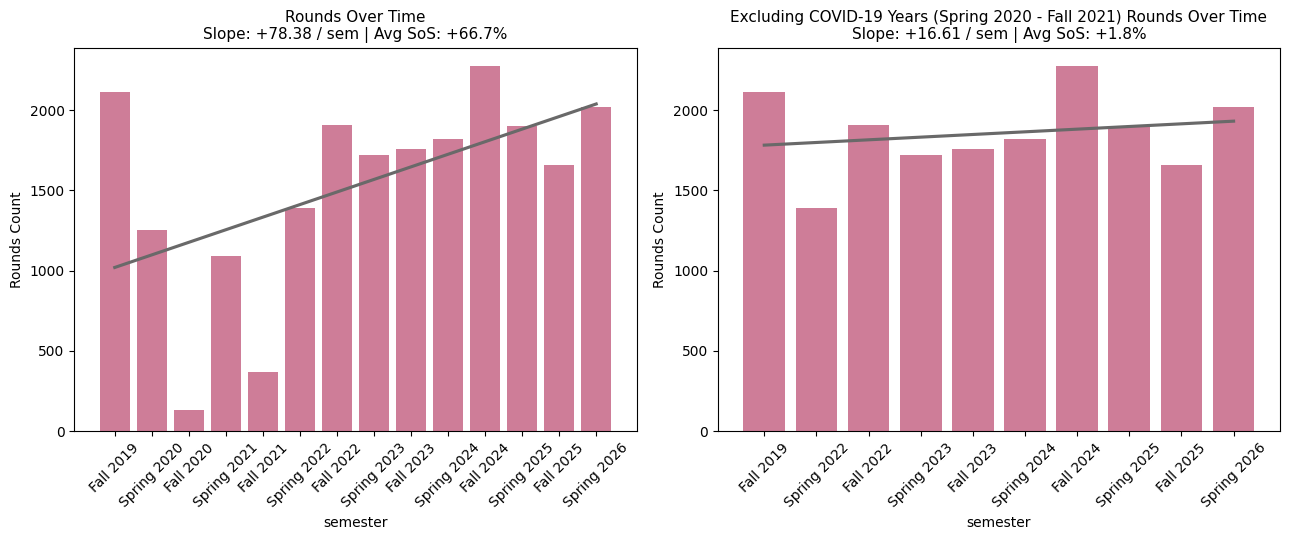

In [26]:
x_positions_t = np.arange(len(total_rounds_df))
slope_t, _ = np.polyfit(x_positions_t, total_rounds_df["total_rounds"], 1)
avg_pct_t = total_rounds_df["total_rounds"].pct_change().mean() * 100

x_positions_r = np.arange(len(total_rounds_df_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, total_rounds_df_exclude_covid["total_rounds"], 1)
avg_pct_r = total_rounds_df_exclude_covid["total_rounds"].pct_change().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(total_rounds_df, x="semester", y="total_rounds", color="palevioletred", ax=axes[0])
sns.regplot(x=x_positions_t, y=total_rounds_df["total_rounds"], ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None)

axes[0].set_title(f"Rounds Over Time\nSlope: {slope_t:+.2f} / sem | Avg SoS: {avg_pct_t:+.1f}%", fontsize=11)
axes[0].set_ylabel("Rounds Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(total_rounds_df_exclude_covid, x="semester", y="total_rounds", color="palevioletred", ax=axes[1])
sns.regplot(x=x_positions_r, y=total_rounds_df_exclude_covid["total_rounds"], ax=axes[1], scatter=False, color="dimgray", label="Trend", ci=None)

axes[1].set_title(
    f"Excluding COVID-19 Years (Spring 2020 - Fall 2021) Rounds Over Time\nSlope: {slope_r:+.2f} / sem | Avg SoS: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Rounds Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

From this, we can see that the slope of rounds is +16.61 in the graph excluding COVID-19 (right), and that there is an average semester-over-semester increase of +1.8%. There does not seem to be as clear cut cycles as the tournaments graph, however, there are periods of increaseing and decreasing totals apparent on the graph. Unlike with tournaments, the highest semesters are in the Fall while the lowest are in Spring. In order to conclude whether is there growth in the number of rounds, we will need to see the data more clearly.

In [27]:
total_rounds_df_exclude_covid['dropped'] = total_rounds_df_exclude_covid['total_rounds'].diff() < 0
total_rounds_df_exclude_covid['period'] = total_rounds_df_exclude_covid['dropped'].cumsum()

is_increasing = total_rounds_df_exclude_covid.groupby('period')['total_rounds'].is_monotonic_increasing
print(is_increasing)

period
0    True
1    True
2    True
3    True
4    True
Name: total_rounds, dtype: bool


Similar to the tournaments, there seem to be cycles within the data, however, unlike the tournaments, it does not seem to neatly correspond to the Spring/Fall intervals.

In [28]:
print(total_rounds_df_exclude_covid)
print("Median: ", total_rounds_df_exclude_covid["total_rounds"].median())
print("Mean: ", total_rounds_df_exclude_covid["total_rounds"].mean())
con.register('tournament_rounds_clean', tournament_rounds_clean)

query = """
SELECT season, SUM(total_rounds) as semester_rounds, COUNT(DISTINCT semester) AS season_count
FROM tournament_rounds_clean
WHERE (
    (semester != 'Spring 2020') And
    (semester != 'Fall 2020') AND
    (semester != 'Spring 2021') AND
    (semester != 'Fall 2021')
)   
GROUP BY season
"""
seasons_rounds_df = con.execute(query).df()
print(seasons_rounds_df)
seasons_rounds_df["avg_rounds"] = seasons_rounds_df["semester_rounds"] / seasons_rounds_df["season_count"]
print(seasons_rounds_df[["season", "avg_rounds"]])

      semester  total_rounds  dropped  period
0    Fall 2019        2117.0    False       0
1  Spring 2022        1391.0     True       1
2    Fall 2022        1906.0    False       1
3  Spring 2023        1722.0     True       2
4    Fall 2023        1756.0    False       2
5  Spring 2024        1822.0    False       2
6    Fall 2024        2276.0    False       2
7  Spring 2025        1900.0     True       3
8    Fall 2025        1662.0     True       4
9  Spring 2026        2022.0    False       4
Median:  1861.0
Mean:  1857.4
   season  semester_rounds  season_count
0  Spring           8857.0             5
1    Fall           9717.0             5
   season  avg_rounds
0  Spring      1771.4
1    Fall      1943.4


From the dropped and period columns displayed we can see the periods of increasing or decreasing total rounds, the most notable being a period of increasing total rounds from Spring 2023 to Fall 2024 and then a period of decreasing total rounds from Fall 2024 to Fall 2025. The number of rounds fluctuates substantially between semesters rather than following a consistent upward trend. Although there are periods of alternating increases and decreases, the pattern is not strictly oscillating, like with the tournaments. Instead, the data suggests considerable semester-to-semester variation, with Fall semesters averaging 1,943.4 rounds compared with 1,771.4 rounds in Spring.

## Deabters

The next metric which we can use to see APDA's growth is the number of active debaters over the years 2019 - 2026. Additionally we will look at the breakdown of first time versus returning debaters during this same period. We will start by selecting all the individual debaters that were active during the period.

In [29]:
debate_roster = pd.read_csv("Data_Curation_Data/Combined_Debaters.csv")

con = duckdb.connect()
con.register('roster', debate_roster)

query = """
SELECT *
FROM roster
WHERE final_year_seen >= 2019 
"""

roster_df = con.execute(query).df()
roster_df.to_csv("APDA_Scope_Data/Active_Debaters.csv", index=False)
print("Number of individuals participating in APDA from 2019 to 2026: ", len(roster_df))

Number of individuals participating in APDA from 2019 to 2026:  3730


From this we can see the total number of individuals who participated in ADPA during 2019 to 2026 was 3,732. Now we can visualize this broken down year by year where the number of debaters active each year are plotted in a bar graph.

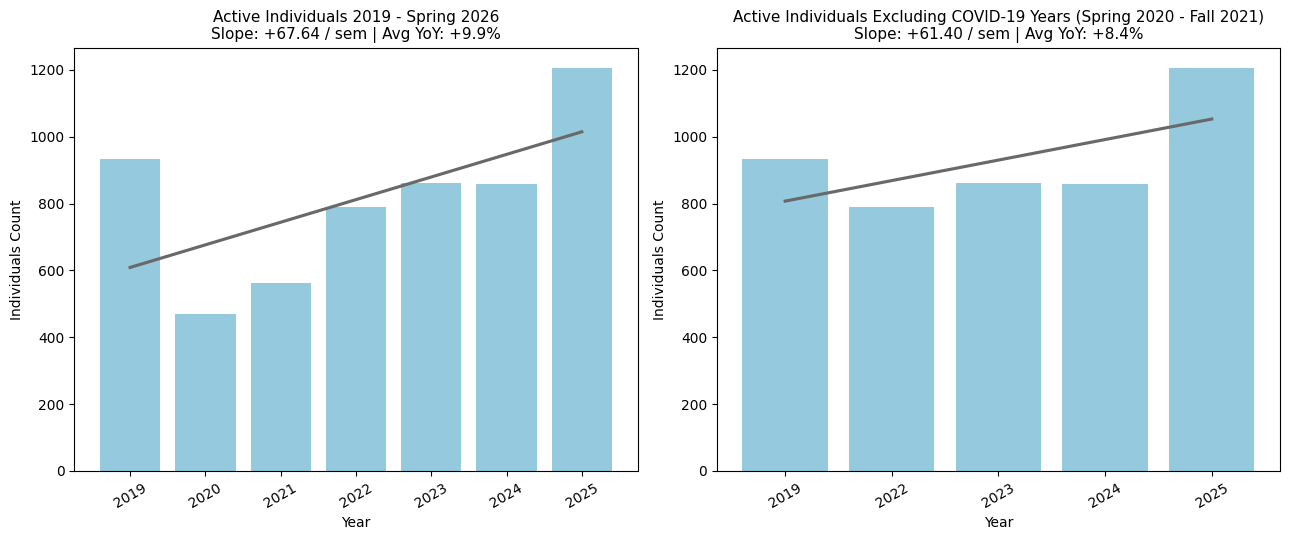

In [31]:
yearly_counts = {}
for year in range(2019, 2026):
    active_count = ((roster_df['initial_year_seen'] <= year) & (roster_df['final_year_seen'] >= year)).sum()
    yearly_counts[year] = active_count

year_data = pd.Series(yearly_counts)

year_data_exclude_covid = year_data.drop(index=2020)
year_data_exclude_covid = year_data_exclude_covid.drop(index=2021)

x_positions_t = np.arange(len(year_data))
slope_t, _ = np.polyfit(x_positions_t, year_data.values, 1)
avg_pct_t = year_data.pct_change().mean() * 100

x_positions_r = np.arange(len(year_data_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, year_data_exclude_covid.values, 1)
avg_pct_r = year_data_exclude_covid.pct_change().mean() * 100


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(x=year_data.index, y=year_data.values, color="skyblue", ax=axes[0])
sns.regplot(x=x_positions_t, y=year_data.values, ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None)

axes[0].set_title(f"Active Individuals 2019 - Spring 2026\nSlope: {slope_t:+.2f} / sem | Avg YoY: {avg_pct_t:+.1f}%", fontsize=11)
axes[0].set_ylabel("Individuals Count")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=year_data_exclude_covid.index, y=year_data_exclude_covid.values, color="skyblue", ax=axes[1])
sns.regplot( x=x_positions_r, y=year_data_exclude_covid.values, ax=axes[1], scatter=False, color="dimgray", label="Trend", ci=None)

axes[1].set_title(
    f"Active Individuals Excluding COVID-19 Years (Spring 2020 - Fall 2021)\nSlope: {slope_r:+.2f} / sem | Avg YoY: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Individuals Count")
axes[1].set_xlabel("Year")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

From this we can see that in the graph excluding COVID-19 years (right) there is a slope of +35.17 and an average semester-over-semester increase of +3.2%. One thing to note about this graph is that although the number of debaters dips in Spring 2020, it does not as steep a decline as the tournaments and rounds graphs do. The following code will show the distinction:

In [32]:
rounds_2019 = df_rounds[df_rounds["year"] == 2019]["round"].count()
rounds_2020 = df_rounds[df_rounds["year"] == 2020]["round"].count()
tournament_2019 = df_rounds[df_rounds["year"] == 2019]["tournament_key"].value_counts().count()
tournament_2020 = df_rounds[df_rounds["year"] == 2020]["tournament_key"].value_counts().count()
debaters_2019 = year_data[2019]
debaters_2020 = year_data[2020]

print("Number of Rounds in 2019: ", rounds_2019, "\nNumber of Rounds in 2020: ", rounds_2020, "\nPercentage Lost: ", (rounds_2020 - rounds_2019) / rounds_2019)
print("Number of Rounds in 2019: ", tournament_2019, "\nNumber of Rounds in 2020: ", tournament_2020, "\nPercentage Lost: ", (tournament_2020 - tournament_2019) / tournament_2019)
print("Number of Rounds in 2019: ", debaters_2019, "\nNumber of Rounds in 2020: ", debaters_2020, "\nPercentage Lost: ", (debaters_2020 - debaters_2019) / debaters_2019)

Number of Rounds in 2019:  1648 
Number of Rounds in 2020:  1167 
Percentage Lost:  -0.29186893203883496
Number of Rounds in 2019:  15 
Number of Rounds in 2020:  12 
Percentage Lost:  -0.2
Number of Rounds in 2019:  934 
Number of Rounds in 2020:  471 
Percentage Lost:  -0.49571734475374735


From this we can see that the rounds decreased by 29%, the tournaments by 20%, and the debaters by 17% during the years of online restriction.

It also is important to know that we are missing the second half of 2026 as the season has not yet completed. We can take the Spring 2026 season out to better visualize the growth year by year as 2026 cannot yet be fairly compared, especially as the Fall season tends to bring in a new crop of novice debaters in their first year of college.

In [33]:
x_positions_t = np.arange(len(year_data))
slope_t, _ = np.polyfit(x_positions_t, year_data.values, 1)
avg_pct_t = year_data.pct_change().mean() * 100

x_positions_r = np.arange(len(year_data_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, year_data_exclude_covid_no_2026.values, 1)
avg_pct_r = year_data_exclude_covid_no_2026.pct_change().mean() * 100


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(x=year_data_no_2026.index, y=year_data_no_2026.values, color="darkseagreen", ax=axes[0])
sns.regplot(x=x_positions_t, y=year_data_no_2026.values, ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None)

axes[0].set_title(f"Active Individuals 2019 - Spring 2026\nSlope: {slope_t:+.2f} / sem | Avg YoY: {avg_pct_t:+.1f}%", fontsize=11)
axes[0].set_ylabel("Individuals Count")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=year_data_exclude_covid_no_2026.index, y=year_data_exclude_covid_no_2026.values, color="darkseagreen", ax=axes[1])
sns.regplot(x=x_positions_r, y=year_data_exclude_covid_no_2026.values, ax=axes[1], scatter=False, color="dimgray", label="Trend", ci=None)

axes[1].set_title(
    f"Active Individuals Excluding COVID-19 Years (Spring 2020 - Fall 2021)\nSlope: {slope_r:+.2f} / sem | Avg YoY: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Individuals Count")
axes[1].set_xlabel("Year")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

KeyError: '[2026] not found in axis'

Now we can clearly see that in the excluding COVID-19 graph (right) there is a slope of +118.1 and an average semester-over-semester increase of +13.3. Further, the number of active participants is clearly steadily increasing per year. To further undertand this growth, lets break the counts down into returning members and members who are new that year. This metric is similar, but not quite the Novice/Varsity distinction that APDA uses since in APDA Novices remain Novice until their second year begins or after their third tournament which ever comes last. Either way, it is a good metric over overall retention to see how many participants are returning versus new that year.

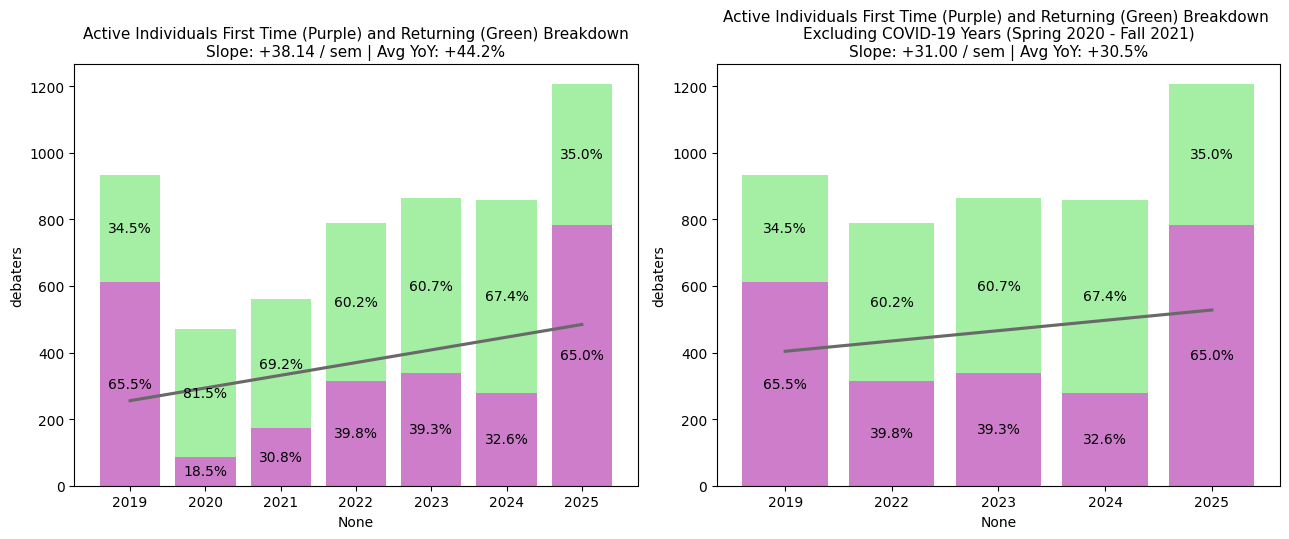

In [35]:
con = duckdb.connect()
con.register('roster', debate_roster)

query = """
SELECT initial_year_seen, COUNT(*) as debaters
FROM roster
WHERE ((initial_year_seen == final_year_seen) and (final_year_seen >= 2019)) 
GROUP BY initial_year_seen
"""
first_time_df = con.execute(query).df()
first_time_no_covid_df = first_time_df[(first_time_df["initial_year_seen"] != 2020) & (first_time_df["initial_year_seen"] != 2021)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

novices = (first_time_df.set_index("initial_year_seen")["debaters"].reindex(year_data.index, fill_value=0))
novices_no_covid = (first_time_no_covid_df.set_index("initial_year_seen")["debaters"].reindex(year_data_exclude_covid.index, fill_value=0))

non_novices = year_data - novices
non_novices_no_covid = year_data_exclude_covid - novices_no_covid

sns.barplot(x=year_data.index, y=novices, color="orchid", ax=axes[0])
sns.barplot(x=year_data.index, y=non_novices, bottom=novices, color="palegreen", ax=axes[0])

for x_pos, year in enumerate(year_data.index):
    total = year_data.loc[year]
    novice = novices.loc[year]
    non_novice = non_novices.loc[year]

    # Non-novice percentage
    if non_novice > 0:
        axes[0].text(x_pos, novice + non_novice / 2, f"{non_novice / total:.1%}", ha="center", va="center")

    # Novice percentage
    if novice > 0:axes[0].text(x_pos, novice / 2, f"{novice / total:.1%}", ha="center", va="center")

sns.barplot(x=year_data_exclude_covid.index, y=novices_no_covid, color="orchid", ax=axes[1])
sns.barplot(x=year_data_exclude_covid.index, y=non_novices_no_covid, bottom=novices_no_covid, color="palegreen", ax=axes[1])

for x_pos, year in enumerate(year_data_exclude_covid.index):
    total = year_data_exclude_covid.loc[year]
    novice = novices_no_covid.loc[year]
    non_novice = non_novices_no_covid.loc[year]

    # Non-novice percentage
    if non_novice > 0: axes[1].text(x_pos, novice + non_novice / 2, f"{non_novice / total:.1%}", ha="center", va="center")

    # Novice percentage
    if novice > 0: axes[1].text(x_pos, novice / 2, f"{novice / total:.1%}", ha="center", va="center")

x_positions_l = np.arange(len(novices))
slope_l, _ = np.polyfit(x_positions_l, novices.values, 1)
avg_pct_l = novices.pct_change().mean() * 100

sns.regplot(x=x_positions_l, y=novices.values, ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None,)
axes[0].set_title(
    f"Active Individuals First Time (Purple) and Returning (Green) Breakdown\nSlope: {slope_l:+.2f} / sem | Avg YoY: {avg_pct_l:+.1f}%",
    fontsize=11,
)

x_positions_r = np.arange(len(novices_no_covid))
slope_r, _ = np.polyfit(x_positions_r, novices_no_covid.values, 1)
avg_pct_r = novices_no_covid.pct_change().mean() * 100

sns.regplot(x=x_positions_r, y=novices_no_covid.values, ax=axes[1], scatter=False, color="dimgray", label="Trend", ci=None)
axes[1].set_title(
    f"Active Individuals First Time (Purple) and Returning (Green) Breakdown \nExcluding COVID-19 Years (Spring 2020 - Fall 2021)\nSlope: {slope_r:+.2f} / sem | Avg YoY: {avg_pct_r:+.1f}%",
    fontsize=11,
)

plt.tight_layout()
plt.show()

Before we begin to analyze, lets drop 2026, the unfinished season, and regraph.

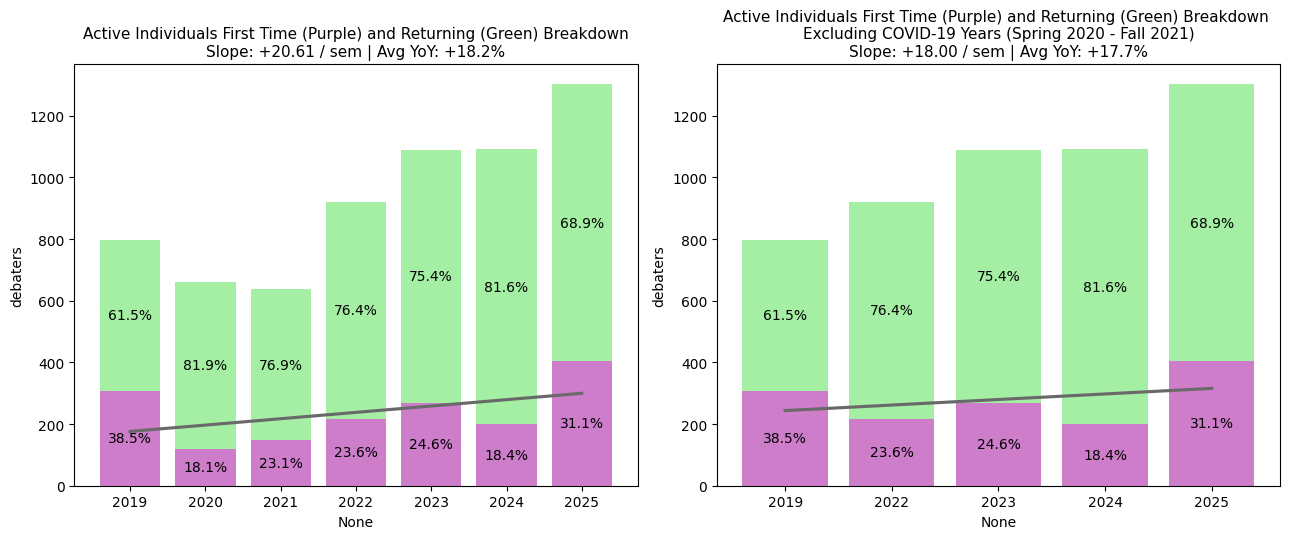

In [41]:
first_time_no_2026 = first_time_df[first_time_df["initial_year_seen"] != 2026]
first_time_exclude_covid_no_2026 = first_time_no_covid_df[first_time_no_covid_df["initial_year_seen"] != 2026]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

novices = (first_time_no_2026.set_index("initial_year_seen")["debaters"].reindex(year_data_no_2026.index, fill_value=0))
novices_no_covid = (first_time_exclude_covid_no_2026.set_index("initial_year_seen")["debaters"].reindex(year_data_exclude_covid_no_2026.index, fill_value=0))

non_novices = year_data_no_2026 - novices
non_novices_no_covid = year_data_exclude_covid_no_2026 - novices_no_covid

sns.barplot(x=year_data_no_2026.index, y=novices, color="orchid", ax=axes[0])
sns.barplot(x=year_data_no_2026.index, y=non_novices, bottom=novices, color="palegreen", ax=axes[0])

for x_pos, year in enumerate(year_data_no_2026.index):
    total = year_data_no_2026.loc[year]
    novice = novices.loc[year]
    non_novice = non_novices.loc[year]

    # Non-novice percentage
    if non_novice > 0:
        axes[0].text(x_pos, novice + non_novice / 2, f"{non_novice / total:.1%}", ha="center", va="center")

    # Novice percentage
    if novice > 0:axes[0].text(x_pos, novice / 2, f"{novice / total:.1%}", ha="center", va="center")

sns.barplot(x=year_data_exclude_covid_no_2026.index, y=novices_no_covid, color="orchid", ax=axes[1])
sns.barplot(x=year_data_exclude_covid_no_2026.index, y=non_novices_no_covid, bottom=novices_no_covid, color="palegreen", ax=axes[1])

for x_pos, year in enumerate(year_data_exclude_covid_no_2026.index):
    total = year_data_exclude_covid_no_2026.loc[year]
    novice = novices_no_covid.loc[year]
    non_novice = non_novices_no_covid.loc[year]

    # Non-novice percentage
    if non_novice > 0: axes[1].text(x_pos, novice + non_novice / 2, f"{non_novice / total:.1%}", ha="center", va="center")

    # Novice percentage
    if novice > 0: axes[1].text(x_pos, novice / 2, f"{novice / total:.1%}", ha="center", va="center")

x_positions_l = np.arange(len(novices))
slope_l, _ = np.polyfit(x_positions_l, novices.values, 1)
avg_pct_l = novices.pct_change().mean() * 100

sns.regplot(x=x_positions_l, y=novices.values, ax=axes[0], scatter=False, color="dimgray", label="Trend", ci=None,)
axes[0].set_title(
    f"Active Individuals First Time (Purple) and Returning (Green) Breakdown\nSlope: {slope_l:+.2f} / sem | Avg YoY: {avg_pct_l:+.1f}%",
    fontsize=11,
)

x_positions_r = np.arange(len(novices_no_covid))
slope_r, _ = np.polyfit(x_positions_r, novices_no_covid.values, 1)
avg_pct_r = novices_no_covid.pct_change().mean() * 100

sns.regplot(x=x_positions_r, y=novices_no_covid.values, ax=axes[1], scatter=False, color="dimgray", label="Trend", ci=None)
axes[1].set_title(
    f"Active Individuals First Time (Purple) and Returning (Green) Breakdown \nExcluding COVID-19 Years (Spring 2020 - Fall 2021)\nSlope: {slope_r:+.2f} / sem | Avg YoY: {avg_pct_r:+.1f}%",
    fontsize=11,
)

plt.tight_layout()
plt.show()

Now we can see that for all finished seasons, the number of first year debaters has a positive slope of +18.0 and an average year-over-year gain of 17.8%, however, there does not seem to be as steady of an increase as the number of active participants. The number of first year debaters and, in fact, the percentages of first year debaters to returning debaters seems to fluctuate per semester.

## Insights and Conclusions

From the metrics analyzed above, the number of tournaments and rounds both fluctuate over time, although tournaments appear to follow a more regular seasonal pattern while rounds vary more sporadically. On average, there are 22.2 tournaments in the Spring and 18.8 tournaments in the Fall. However, the average number of rounds is lower in the Spring than in the Fall, with 1,771.4 and 1,943.4 rounds, respectively. This is an interesting finding because, despite Fall having fewer tournaments on average, it has more total rounds. This could suggest that Fall tournaments tend to host more rounds per tournament, potentially placing a greater hosting burden on teams during the Fall by concentrating more rounds among fewer tournaments.

The number of active debaters, meanwhile, shows a clear empirical increase over time, while the number of first-year debaters fluctuates substantially from year to year. This suggests that APDA's overall participant base has grown, but the rate at which new debaters enter the organization is considerably less consistent. 

The question I would then like to pose for future research is the following: why does an increase in active participants not result in an increase of total participation, measured in rounds and tournaments? 